In [ ]:
print("Titanic Survival")

In [2]:
#Import the required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

In [3]:
#Dataset Loading
df = pd.read_csv("Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
#Handling Missing Values
print("Dataset Shape:")
print(df.shape)
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape:
(891, 12)

Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


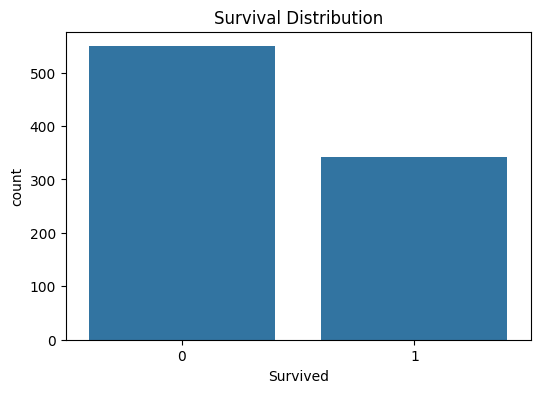

In [5]:
plt.figure(figsize=(6,4))
sns.countplot(
    x="Survived",
    data=df
)
plt.title("Survival Distribution")
plt.show()

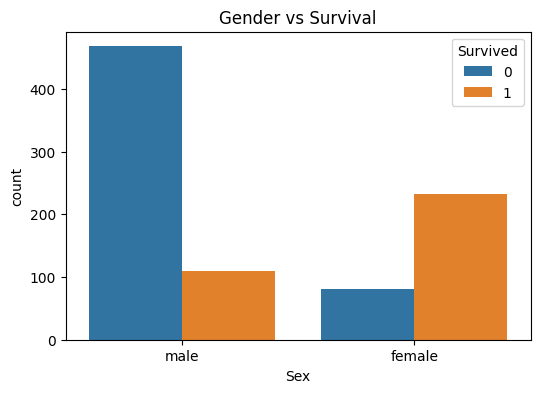

In [6]:
plt.figure(figsize=(6,4))
sns.countplot(
    x="Sex",
    hue="Survived",
    data=df
)
plt.title("Gender vs Survival")
plt.show()

In [8]:
df["Age"].fillna(df["Age"].median(), inplace=True)
df["Embarked"].fillna(
    df["Embarked"].mode()[0],
    inplace=True
)

/tmp/ipykernel_545/827127559.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].median(), inplace=True)


In [10]:
df["Sex"] = df["Sex"].map({
    "male":0,
    "female":1
})
df["Embarked"] = df["Embarked"].map({
    "S":0,
    "C":1,
    "Q":2
})

In [11]:
X = df[
    [
        "Pclass",
        "Sex",
        "Age",
        "SibSp",
        "Parch",
        "Fare",
        "Embarked"
    ]
]

y = df["Survived"]

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [13]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
model.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

In [14]:
predictions = model.predict(X_test)

In [15]:
accuracy = accuracy_score(
    y_test,
    predictions
)
print("Accuracy:",accuracy)

Accuracy: 0.7318435754189944


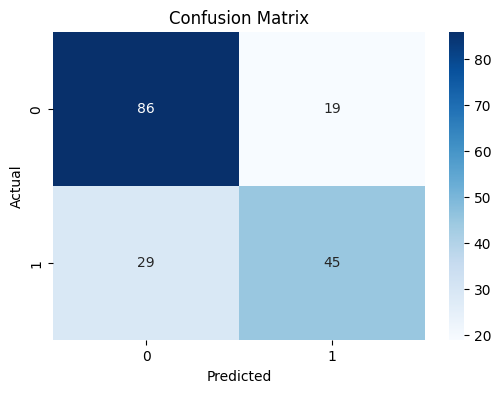

In [16]:
cm = confusion_matrix(
    y_test,
    predictions
)
plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

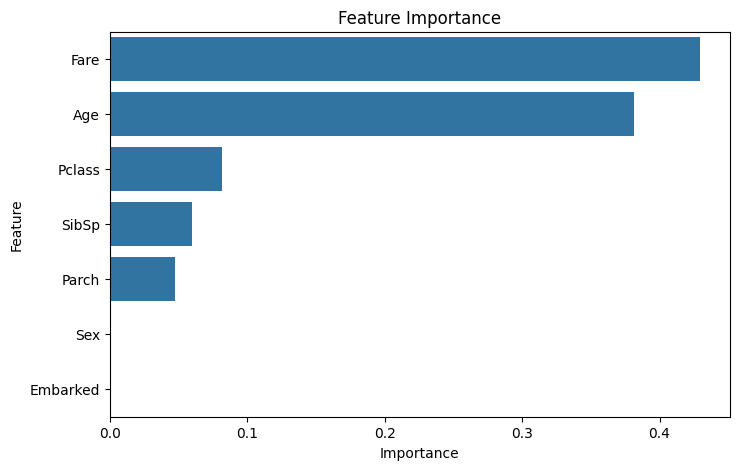

In [17]:
importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":model.feature_importances_
})
importance = importance.sort_values(
    by="Importance",
    ascending=False
)
plt.figure(figsize=(8,5))
sns.barplot(
    x="Importance",
    y="Feature",
    data=importance
)
plt.title("Feature Importance")
plt.show()

In [18]:
print("""
Conclusion:

The Random Forest model was used to predict
whether a passenger survived the Titanic disaster.

The model achieved good accuracy and identified
important factors such as Sex, Fare and Pclass
that influenced survival.
""")


Conclusion:

The Random Forest model was used to predict
whether a passenger survived the Titanic disaster.

The model achieved good accuracy and identified
important factors such as Sex, Fare and Pclass
that influenced survival.

